# Week 2 — From Physical Events to Trustworthy Samples
### Solution / instructor notebook (runs top-to-bottom)

> **Story question:** How can a digital recording contain a frequency that was *never* present in the physical event?

**Flow:** high-rate reference → sample at several rates → compare → predict aliases → quantize at several bit depths → measure error → audit timestamps.

This notebook is the **source of truth** for every number and figure in the Week 2 slides and worksheet.
It builds four reusable toolbox functions — `sample_signal`, `predict_alias_frequency`,
`quantize_uniform`, `check_timebase` — each with a synthetic self-check.

*Convention note:* quantization uses the **mid-rise** rule (Δ = range / 2ᵇ, centered levels), which is the
convention for which SNR ≈ 6.02·b + 1.76 dB holds. Week 1 used endpoint levels; Part C shows the difference.

Generate sine wave at high sampling rate to be an analog signal

In [1]:
import numpy as np
def time_axis(fs, duration):
    T = 1/fs
    t = np.arange(0, duration, T)
    return t
def generate_sine(f, t, A=1, p=0):
    y = A * np.sin(2 * np.pi * f * t + p)
    return y

10000


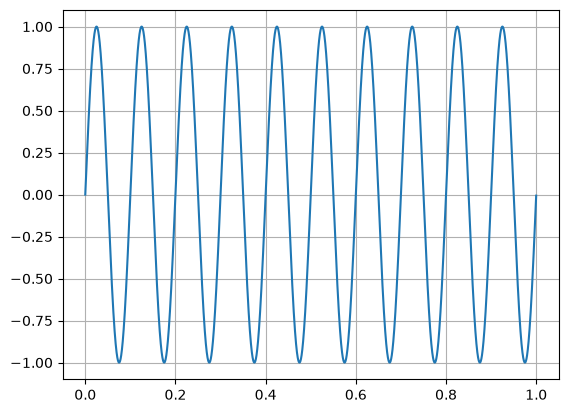

In [2]:
fs_analog = 10000
duration = 1
t_analog = time_axis(fs_analog, duration)
print(len(t_analog))
y_analog = generate_sine(f=10, t = t_analog)

import matplotlib.pyplot as plt

plt.plot(t_analog, y_analog)
plt.grid()
plt.show()

2000
Sampling time axis: [0.  0.2 0.4 0.6 0.8]
Sampling value    : [ 0.00000000e+00 -4.89858720e-16 -9.79717439e-16 -1.46957616e-15
 -1.95943488e-15]


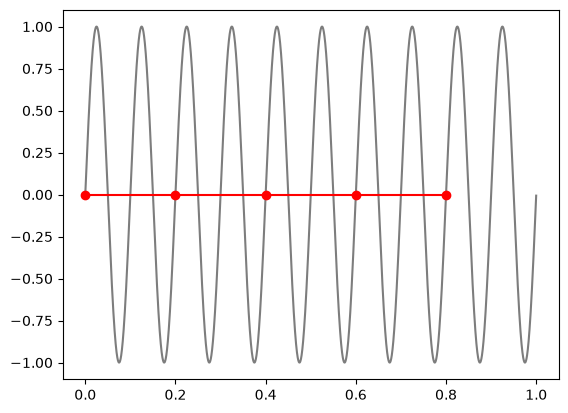

In [4]:
fs = 5
step = fs_analog // fs
print(step)
t = t_analog[::step]
y = y_analog[::step]
print("Sampling time axis:", t)
print("Sampling value    :", y)

plt.plot(t_analog, y_analog, color="#7d7d7d")
plt.plot(t, y, 'or-')
plt.show()

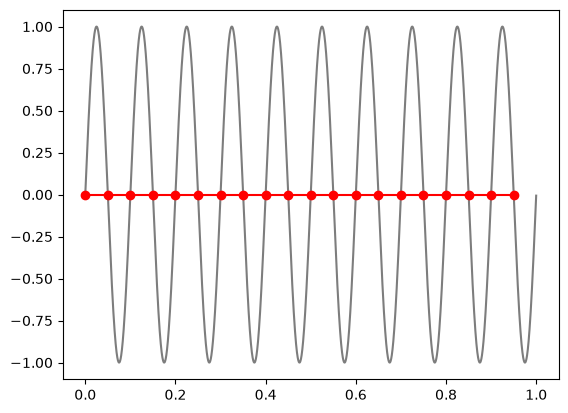

In [5]:
fs = 20
step = fs_analog // fs
# print(step)
t = t_analog[::step]
y = y_analog[::step]
# print("Sampling time axis:", t)
# print("Sampling value    :", y)

plt.plot(t_analog, y_analog, color="#7d7d7d")
plt.plot(t, y, 'or-')
plt.show()

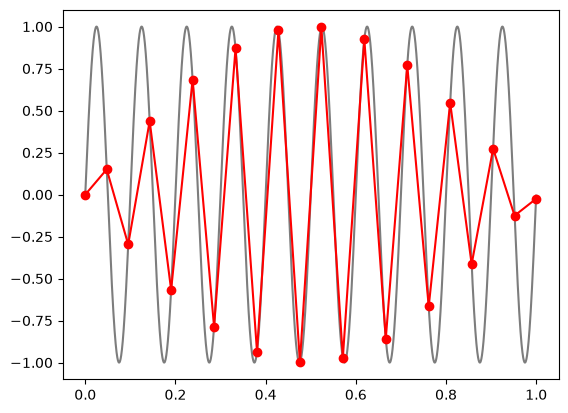

In [6]:
fs = 21

step = fs_analog // fs
# print(step)
t = t_analog[::step]
y = y_analog[::step]
# print("Sampling time axis:", t)
# print("Sampling value    :", y)

plt.plot(t_analog, y_analog, color="#7d7d7d")
plt.plot(t, y, 'or-')
plt.show()

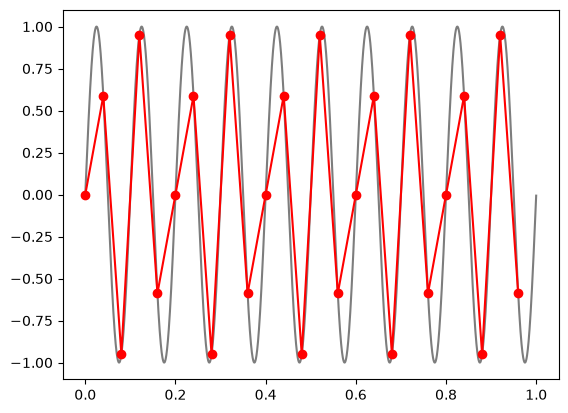

In [7]:
fs = 25
step = fs_analog // fs
# print(step)
t = t_analog[::step]
y = y_analog[::step]
# print("Sampling time axis:", t)
# print("Sampling value    :", y)

plt.plot(t_analog, y_analog, color="#7d7d7d")
plt.plot(t, y, 'or-')
plt.show()

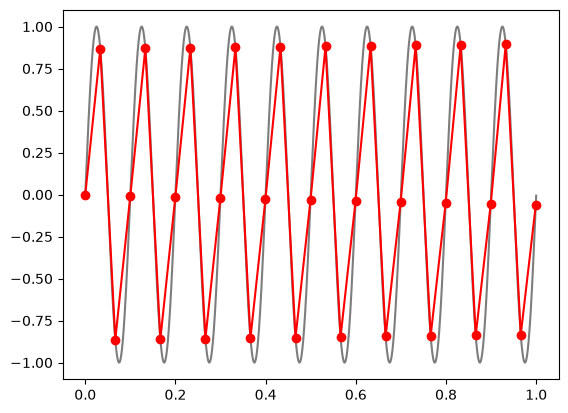

In [8]:
fs = 30
step = fs_analog // fs
# print(step)
t = t_analog[::step]
y = y_analog[::step]
# print("Sampling time axis:", t)
# print("Sampling value    :", y)

plt.plot(t_analog, y_analog, color="#7d7d7d")
plt.plot(t, y, 'or-')
plt.show()

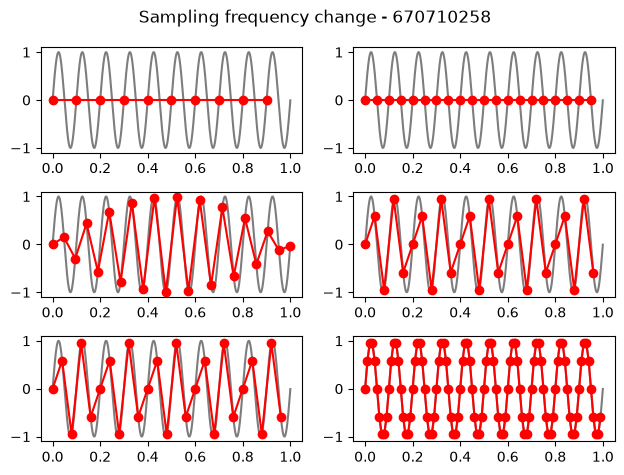

<Figure size 640x480 with 0 Axes>

In [29]:
# Ex1 แสดงผลการชักตัวอย่างที่ 10, 20, 21, 25, 30, และ 100 Hz ใน plot เดียวกัน โดยแยกเป็น subplot 3 แถว 2 หลัก
fs1 = 10
step1 = fs_analog // fs1
t1 = t_analog[::step1]
y1 = y_analog[::step1]

plt.subplot(3, 2, 1)
plt.plot(t_analog, y_analog, color="#7d7d7d")
plt.plot(t1, y1, 'or-')

fs2 = 20
step2 = fs_analog // fs2
t2 = t_analog[::step2]
y2 = y_analog[::step2]

plt.subplot(3, 2, 2)
plt.plot(t_analog, y_analog, color="#7d7d7d")
plt.plot(t2, y2, 'or-')

fs3 = 21
step3 = fs_analog // fs3
t3 = t_analog[::step3]
y3 = y_analog[::step3]

plt.subplot(3, 2, 3)
plt.plot(t_analog, y_analog, color="#7d7d7d")
plt.plot(t3, y3, 'or-')

fs4 = 25
step4 = fs_analog // fs4
t4 = t_analog[::step4]
y4 = y_analog[::step4]

plt.subplot(3, 2, 4)
plt.plot(t_analog, y_analog, color="#7d7d7d")
plt.plot(t4, y4, 'or-')

fs5 = 30
step5 = fs_analog // fs5
t5 = t_analog[::step4]
y5 = y_analog[::step4]

plt.subplot(3, 2, 5)
plt.plot(t_analog, y_analog, color="#7d7d7d")
plt.plot(t5, y5, 'or-')

fs6 = 100
step6 = fs_analog // fs6
t6 = t_analog[::step6]
y6 = y_analog[::step6]

plt.subplot(3, 2, 6)
plt.plot(t_analog, y_analog, color="#7d7d7d")
plt.plot(t6, y6, 'or-')

plt.suptitle('Sampling frequency change - 670710258')
plt.tight_layout()
plt.show()
plt.savefig('670710258_w2_ex1.png')


400


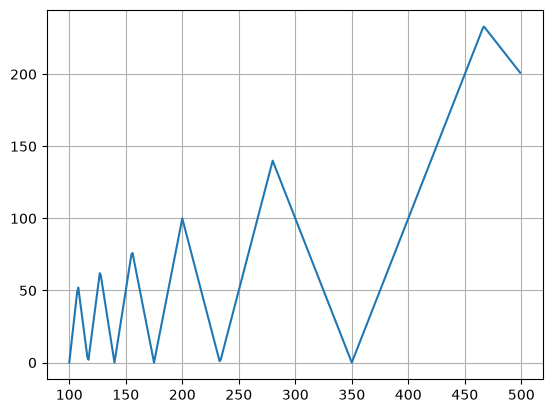

In [45]:
# Ex2 คำนวณค่าความถี่ปรากฏ ของสัญญาณความถี่ที่ 100 Hz เมื่อใช้ค่าการชักตัวอย่างจาก 100 - 300 Hz (200 ค่า)
# Plot ผลลัพธ์การคำนวณ ความถี่ปรากฏ (แกน y) คู่กับความถี่การชักตัวอย่าง (แกน x)

fs = np.arange(100, 500, 1)
print(len(fs))
# print(fs)

f = 700 #check f = 700
fa= []
# for i in fs:
fa = np.abs(f - fs * np.round(f/fs))
# print(fa)

plt.plot(fs, fa)
plt.grid()
plt.show()


Quantization and errors

In [31]:
# Ex3 ทำ Quantization ค่า x ให้อยู่ในช่วง 1 ถึง -1 ที่ระดับ 2 bits และแสดงค่า xq
x_min = -1
x_max = 1
n_bits = 2
L = 2**n_bits
delta = (x_max - x_min)/L
# x = 0.9
x = 0.9
k = np.floor((x - x_min)/delta)
# print(k)
x_q = x_min + (k + 0.5) * delta
print(x_q)

# x = 0.3
x = 0.3
k = np.floor((x - x_min)/delta)
# print(k)
x_q = x_min + (k + 0.5) * delta
print(x_q)

# x = 0.1
x = 0.1
k = np.floor((x - x_min)/delta)
# print(k)
x_q = x_min + (k + 0.5) * delta
print(x_q)



0.75
0.25
0.25


In [82]:
# Ex4 สร้าง function สำหรับการทำ quantization ที่สามารถรับค่า x ได้แบบหลายค่า (list, np)
def quantize_uniform(x, n_bits, x_min, x_max):
    L = 2**n_bits
    delta = (x_max - x_min)/L
    k = np.floor((x - x_min)/delta)
    x_q = x_min + (k+0.5)*delta
    return x_q
    

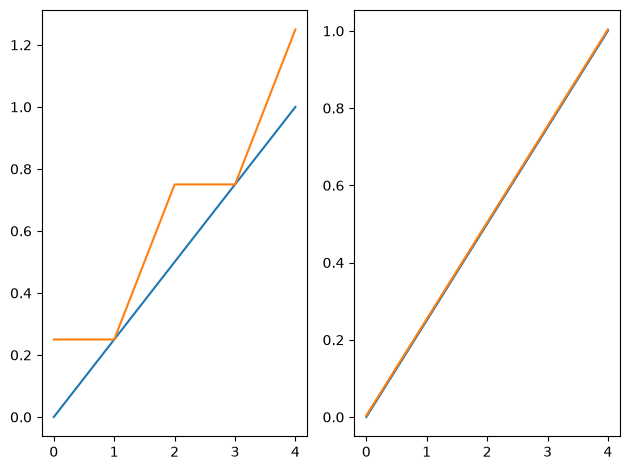

In [95]:
x = np.linspace(0, 1, 5)
# Ex4.1 ทำ Quantization กับค่า x ให้อยู่ในช่วง 1 ถึง -1 ที่ระดับ 2 bits และ plot ผลลัพธ์เทียบกัน (ดูตัวอย่างในสไลด์ 58)
xq = quantize_uniform(x, 2, -1, 1)

plt.subplot(1, 2, 1)
plt.plot(x)
plt.plot(xq)
# Ex4.2 ทำ Quantization ในช่วง 1 ถึง -1 ที่ระดับ 8 bits
xq = quantize_uniform(x, 8, -1, 1)

plt.subplot(1, 2, 2)
plt.plot(x)
plt.plot(xq)

plt.tight_layout()
plt.show()


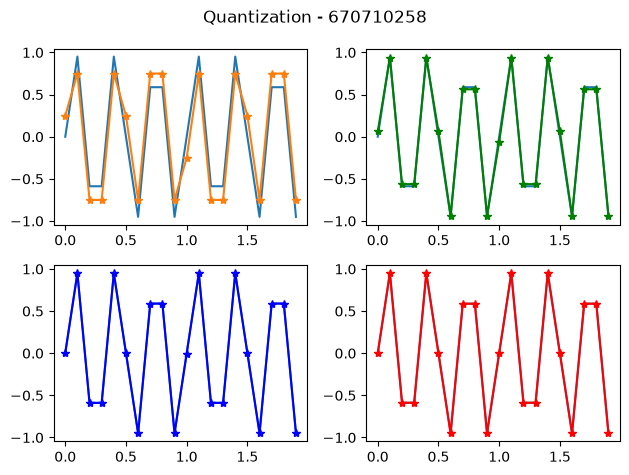

In [111]:
# Ex4.3 plot ผลลัพธ์ในรูปแบบ 2x2 subplot
# สร้าง sine wave ที่ความถี่ 3 Hz มีค่า A เป็น 1  โดยชักตัวอย่างที่ 10 Hz เป็นเวลา 2 วินาที
fs = 10
duration = 2
f = 3
t = time_axis(fs = 10, duration = 2)
y= generate_sine(f=f, t = t)


# ทำ Quantization ในช่วง 1 ถึง -1 ที่ระดับ 2 bits
xq = quantize_uniform(y, 2, -1, 1)
plt.subplot(2, 2, 1)
plt.plot(t, y)
plt.plot(t, xq, marker='*')

# ทำ Quantization ในช่วง 1 ถึง -1 ที่ระดับ 4 bits
xq = quantize_uniform(y, 4, -1, 1)
plt.subplot(2, 2, 2)
plt.plot(t, y)
plt.plot(t, xq, marker='*', color ='g')

# ทำ Quantization ในช่วง 1 ถึง -1 ที่ระดับ 8 bits
xq = quantize_uniform(y, 8, -1, 1)
plt.subplot(2, 2, 3)
plt.plot(t, y)
plt.plot(t, xq, marker='*', color ='b')

# ทำ Quantization ในช่วง 1 ถึง -1 ที่ระดับ 16 bits
xq = quantize_uniform(y, 16, -1, 1)
plt.subplot(2, 2, 4)
plt.plot(t, y)
plt.plot(t, xq, marker='*', color ='r')

plt.suptitle('Quantization - 670710258')
plt.tight_layout()
plt.show()



In [94]:
# Ex5 ทำ Quantization ในช่วง 1 ถึง -1 ที่ระดับ 2 bits ของค่า x ที่กำหนด และแสดงค่า Quantization error
# x = 0.8
x_q = quantize_uniform(0.8, 2, -1, 1)
print(x_q)
# x = 0.4
x_q = quantize_uniform(0.4, 2, -1, 1)
print(x_q)
# x = 0.6
x_q = quantize_uniform(0.6, 2, -1, 1)
print(x_q)
# x = 0.2
x_q = quantize_uniform(0.2, 2, -1, 1)
print(x_q)


0.75
0.25
0.75
0.25


In [32]:
# Ex6 คำนวณค่า Quantization error แบบ RMSE ของสัญญาณต่อไปนี้
# 6.1 x = np.linspace(0, 1, 5)
x = np.linspace(0, 1, 5)
x_q = quantize_uniform(x, 2, -1, 1)
eq = np.abs(x -x_q)

rmse = np.sqrt(np.sum(eq**2)/len(eq) )
print(rmse)

# 6.2 sine wave ที่ความถี่ 2 Hz A=1 ถูก sampling ที่ 8 Hz เป็นเวลา 1 วินาที

fs = 8
duration = 1
f = 2
# t = time_axis(fs = fs, duration = duration)
y= generate_sine(f=f, t = x)

y_q = quantize_uniform(y, 2, -1, 1)
eq = np.abs(y -y_q)

rmse = np.sqrt(np.sum(eq**2)/len(eq) )
print(rmse)


NameError: name 'quantize_uniform' is not defined

In [130]:
# 6.3 สร้าง sine wave ที่ความถี่และ A ใดก็ได้ โดยต้องถูก sampling ตามกฏของ Nyquist เป็นช่วงเวลาใดก็ได้ 
# แสดงค่า RMSE เมื่อทำ Quantization ในช่วง 1 ถึง -1 ที่ 2, 4, 8, และ 16 bits
fs = 8
duration = 1
f = 2
# t = time_axis(fs = fs, duration = duration)
y= generate_sine(f=f, t = x)

y_q = quantize_uniform(y, 2, -1, 1)
eq = np.abs(y -y_q)

rmse = np.sqrt(np.sum(eq**2)/len(eq) )
print(rmse)

y_q = quantize_uniform(y, 4, -1, 1)
eq = np.abs(y -y_q)

rmse = np.sqrt(np.sum(eq**2)/len(eq) )
print(rmse)

y_q = quantize_uniform(y, 8, -1, 1)
eq = np.abs(y -y_q)

rmse = np.sqrt(np.sum(eq**2)/len(eq) )
print(rmse)

y_q = quantize_uniform(y, 16, -1, 1)
eq = np.abs(y -y_q)

rmse = np.sqrt(np.sum(eq**2)/len(eq) )
print(rmse)

0.24999999999999978
0.06249999999999976
0.003906249999999755
1.525878906225507e-05
